# Unit 1: R for Data Mining 
## 1. Intro to Modern Data Mining
#### Load the dataset and provide an overview of its structure (e.g., dimensions, missing values, types of variables).

#### Explain why data mining is important for this dataset.

In [24]:
library(dplyr)
library(ggplot2)
library(rpart) 
library(caret)       
library(randomForest)

model <- read.csv("/kaggle/input/datasets/drei04/customerchurn/customer_churn.csv")

head(model)
dim(model) 
str(model)      
summary(model)    
names(model)

colSums(is.na(model))

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,CUST00001,Male,0,No,No,65,Yes,Fiber optic,Month-to-month,20.04,1302.60,No
2,CUST00002,Male,0,No,No,26,Yes,Fiber optic,Month-to-month,65.14,1693.64,No
3,CUST00003,Male,0,Yes,No,54,Yes,Fiber optic,Month-to-month,49.38,2666.52,No
4,CUST00004,Female,0,Yes,Yes,70,Yes,DSL,One year,31.19,2183.30,No
5,CUST00005,Male,0,No,No,53,Yes,DSL,Month-to-month,103.86,5504.58,Yes
6,CUST00006,Female,0,No,Yes,45,Yes,Fiber optic,Month-to-month,87.34,3930.30,Yes


[1] 10000    12

'data.frame':	10000 obs. of  12 variables:
 $ CustomerID     : chr  "CUST00001" "CUST00002" "CUST00003" "CUST00004" ...
 $ Gender         : chr  "Male" "Male" "Male" "Female" ...
 $ SeniorCitizen  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner        : chr  "No" "No" "Yes" "Yes" ...
 $ Dependents     : chr  "No" "No" "No" "Yes" ...
 $ Tenure         : int  65 26 54 70 53 45 35 20 48 33 ...
 $ PhoneService   : chr  "Yes" "Yes" "Yes" "Yes" ...
 $ InternetService: chr  "Fiber optic" "Fiber optic" "Fiber optic" "DSL" ...
 $ Contract       : chr  "Month-to-month" "Month-to-month" "Month-to-month" "One year" ...
 $ MonthlyCharges : num  20 65.1 49.4 31.2 103.9 ...
 $ TotalCharges   : num  1303 1694 2667 2183 5505 ...
 $ Churn          : chr  "No" "No" "No" "No" ...


  CustomerID           Gender          SeniorCitizen      Partner         
 Length:10000       Length:10000       Min.   :0.0000   Length:10000      
 Class :character   Class :character   1st Qu.:0.0000   Class :character  
 Mode  :character   Mode  :character   Median :0.0000   Mode  :character  
                                       Mean   :0.1502                     
                                       3rd Qu.:0.0000                     
                                       Max.   :1.0000                     
  Dependents            Tenure      PhoneService       InternetService   
 Length:10000       Min.   : 0.00   Length:10000       Length:10000      
 Class :character   1st Qu.:17.00   Class :character   Class :character  
 Mode  :character   Median :35.00   Mode  :character   Mode  :character  
                    Mean   :35.22                                        
                    3rd Qu.:53.00                                        
                    Max.   :71.

[1] "CustomerID"      "Gender"          "SeniorCitizen"   "Partner"        
 [5] "Dependents"      "Tenure"          "PhoneService"    "InternetService"
 [9] "Contract"        "MonthlyCharges"  "TotalCharges"    "Churn"

CustomerID          Gender   SeniorCitizen         Partner      Dependents 
              0               0               0               0               0 
         Tenure    PhoneService InternetService        Contract  MonthlyCharges 
              0               0               0               0               0 
   TotalCharges           Churn 
              0               0

## 2. Data Visualization
#### Create at least three meaningful visualizations to explore relationships in the data (e.g., churn rate by tenure, service type, or monthly charges).

#### Provide insights based on the visualizations.





`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


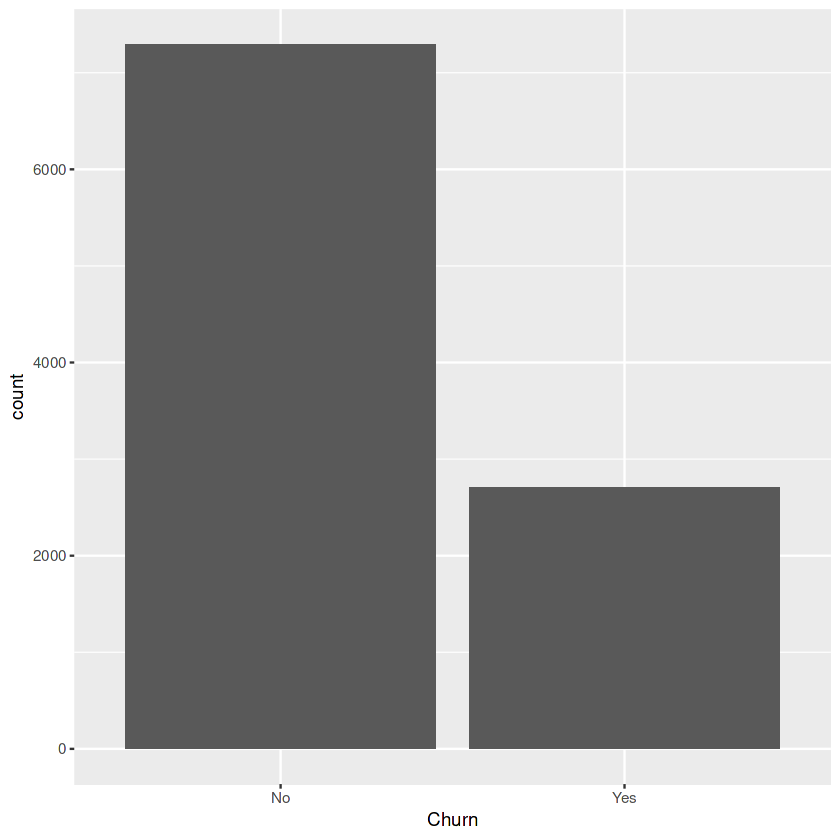

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


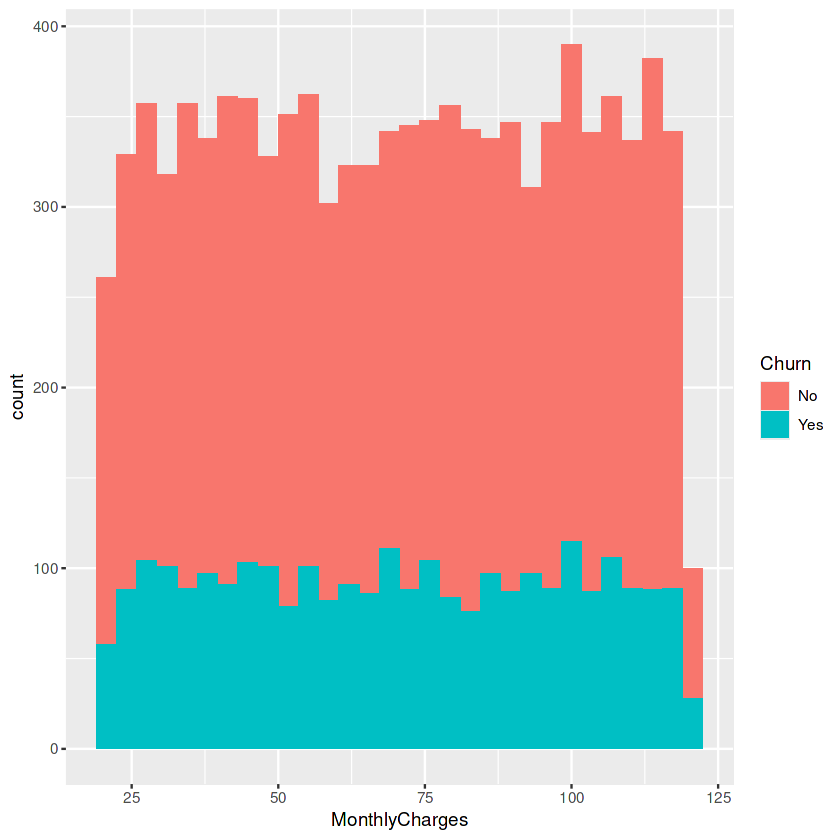

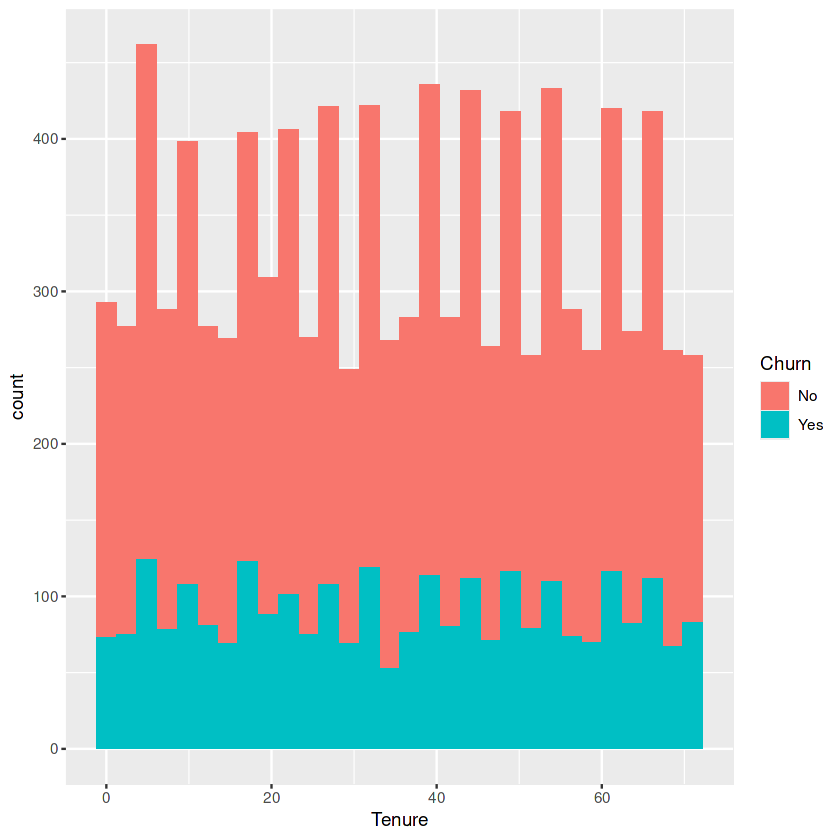

In [8]:
ggplot(model) +
  aes(Churn) +
  geom_bar()

# Monthly charges vs churn
ggplot(model) +
  aes(MonthlyCharges, fill = Churn) +
  geom_histogram()

# Tenure vs churn
ggplot(model) +
  aes(Tenure, fill = Churn) +
  geom_histogram()


# Insights:
# - Customers with shorter tenure tend to churn more often.
# - Higher monthly charges may be associated with higher churn.
# - The churn distribution shows how many customers leave vs stay.

# 3. Data Transformation
#### Handle missing values appropriately.

#### Convert categorical variables into factor variables.

#### Normalize or standardize numerical features where necessary.



In [11]:
model <- na.omit(model)

factor_cols <- c("Churn", "Contract", "InternetService", "Gender", "Partner", "Dependents", "PhoneService", "SeniorCitizen")
model[factor_cols] <- lapply(model[factor_cols], as.factor)

model$MonthlyCharges <- scale(model$MonthlyCharges)

# 4. Data Wrangling
#### Filter data to remove outliers.

#### Create new derived variables that may help in predictive modeling.

#### Aggregate or summarize data if necessary.

In [13]:
Q1 <- quantile(model$MonthlyCharges, 0.25)
Q3 <- quantile(model$MonthlyCharges, 0.75)
IQR <- Q3 - Q1

model <- model %>%
  filter(MonthlyCharges > (Q1 - 1.5*IQR) &
         MonthlyCharges < (Q3 + 1.5*IQR))

model$charge_per_month <- model$MonthlyCharges / (model$Tenure + 1)

model %>%
  group_by(Churn) %>%
  summarise(count = n())

Churn,count
<fct>,<int>
No,7294
Yes,2706


# 5. Review 

### Key takeaways:
#### - Visualizations usually reveal relationships between features and in this dataset, we see the relationships between churn, tenure, and charges.
#### - Data transformation and wrangling prepares the dataset for analysis by making it easier to remove outlier and create more useful variables.
#### - These steps improve the quality of data before building predictive models just like how you taught us back in EDA classes.

# Unit 2: Tuning Predictive Models
### 6 & 8. Model Complexity & Cross-Validation

#### Fit a decision tree and logistic regression model.

#### Compare their complexities and explain trade-offs.

#### For decision tree it's prone for overfitting but can handle complex calculations involving non-linear relationships while Logistic Regression is better for binary classifications or linear relationships, it's usually not prone for overfitting unless predictors are too many. Usually logistic regression is used for smaller datasets and decision tree for bigger datasets. If asked to choose between the two for this dataset I believe decision tree is better.


#### Use k-fold cross-validation (k=10) to evaluate model performance.

#### Report and interpret accuracy, precision, recall, and F1-score.

#### For Accuracy, on average, the model correctly predicts  about 73% of the samples but the Kappa being 0 suggests class imbalance or there is bias on the majority class. Logistic regression is stable and linear but since the Kappa is low there might be missing complex interactions.

In [47]:
library(caret)
library(rpart)

# Ensure Churn is a 2-level factor
model$Churn <- as.factor(model$Churn)

# Convert other character columns to factors
model[] <- lapply(model, function(x) if(is.character(x)) as.factor(x) else x)

#sir AI yung dalawang line sa taas puro error kase since nag hahanap ng factor na 2 levels para dun sa library ng caret o di kaya naman sobrang tagal mag run. yung baba na yung sariling code

set.seed(123)

ctrl <- trainControl(method = "cv", number = 10)

log_cv <- train(Churn ~ ., data = model[, -1],  
                method = "glm",
                family = "binomial",
                trControl = ctrl)


tree_cv <- train(Churn ~ ., data = model[, -1],
                 method = "rpart",
                 trControl = ctrl)

log_cv
tree_cv

Generalized Linear Model 

10000 samples
   10 predictor
    2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 9000, 8999, 9001, 9000, 9001, 9000, ... 
Resampling results:

  Accuracy   Kappa
  0.7294001  0    


CART 

10000 samples
   10 predictor
    2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 9001, 9001, 9000, 8999, 8999, 9000, ... 
Resampling results across tuning parameters:

  cp            Accuracy   Kappa        
  0.0004619364  0.7143087  -0.0062676047
  0.0004751346  0.7144087  -0.0063878442
  0.0018477458  0.7293001   0.0001399211

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.001847746.

### Bias-Variance Trade-Off

#### Explain the concept of bias-variance trade-off in the context of the models trained.

#### Discuss how model complexity affects performance.

#### Bias: Error from overly simple models (e.g., logistic regression may underfit).

#### Variance: Error from overly complex models (e.g., deep decision trees overfit training data).

#### Trade-Off: Increasing complexity reduces bias but increases variance; simpler models have higher bias but lower variance.

#### Decision trees have lower bias, higher variance. Logistic regression has higher bias, lower variance.

# 9. Classification
#### Train a Random Forest classifier to predict customer churn.

#### Tune hyperparameters using grid search.

#### Report final model performance.

In [48]:
rf_grid <- expand.grid(
  mtry = c(2, 4, 6, 8)  
)

rf_cv <- train(Churn ~ ., 
               data = model[, -1],    
               method = "rf",
               trControl = ctrl,
               tuneGrid = rf_grid,
               ntree = 500,           
               importance = TRUE)     


rf_cv

Random Forest 

10000 samples
   10 predictor
    2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 9000, 9000, 9000, 8999, 9000, 9000, ... 
Resampling results across tuning parameters:

  mtry  Accuracy   Kappa       
  2     0.7294000   0.000000000
  4     0.7182994  -0.001813645
  6     0.7011994  -0.008782265
  8     0.6970990  -0.015520654

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was mtry = 2.

# 10. Logicstic Regression
#### Fit a logistic regression model using Churn as the dependent variable and Tenure, MonthlyCharges, and TotalCharges as independent variables.

#### Interpret the coefficients and assess model significance using p-values.

In [49]:
model$Churn <- as.factor(model$Churn)

log_model <- glm(Churn ~ Tenure + MonthlyCharges + TotalCharges,
                 data = model,
                 family = "binomial")

summary(log_model)


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = "binomial", data = model)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.062e+00  1.174e-01  -9.045   <2e-16 ***
Tenure          2.899e-03  2.812e-03   1.031    0.303    
MonthlyCharges  7.066e-04  1.543e-03   0.458    0.647    
TotalCharges   -3.319e-05  3.739e-05  -0.888    0.375    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 11677  on 9999  degrees of freedom
Residual deviance: 11676  on 9996  degrees of freedom
AIC: 11684

Number of Fisher Scoring iterations: 4


# 11. Regression in High Dimensions

#### Discuss the challenges of high-dimensional regression and potential solutions.
#### High-Dimensional Regression usually has many predictors which is why it's called high-dimensional which means it's prone to overfitting and unstable results. Normal logistic regressions sometimes fail because the number of predictors is higher than the observations. We can reduce these problems by regulating them using ridge,lasso, or elastic net. We can also reduce dimensions by selecting features and cross-validating to avoid overfitting.

#### Apply Principal Component Analysis (PCA) on numerical features (Tenure, MonthlyCharges, TotalCharges) to reduce dimensionality.


In [50]:
library(stats)

num_features <- model[, c("Tenure", "MonthlyCharges", "TotalCharges")]

num_scaled <- scale(num_features)

pca_result <- prcomp(num_scaled, center = TRUE, scale. = TRUE)

summary(pca_result)

pca_scores <- data.frame(pca_result$x[, 1:2], Churn = model$Churn)

Importance of components:
                          PC1    PC2     PC3
Standard deviation     1.3862 1.0123 0.23130
Proportion of Variance 0.6405 0.3416 0.01783
Cumulative Proportion  0.6405 0.9822 1.00000

# 12. Ridge Regression

#### Implement Ridge Regression using Churn as the target variable and Tenure, MonthlyCharges, TotalCharges, and additional customer demographic features as predictors.

#### Identify the optimal lambda using cross-validation. (4.5349)

In [52]:
library(glmnet)

x <- model.matrix(Churn ~ Tenure + MonthlyCharges + TotalCharges + Gender + SeniorCitizen + Partner + Dependents, data = model)[, -1]
y <- model$Churn

set.seed(123)
ridge_cv <- cv.glmnet(x, y, family = "binomial", alpha = 0, nfolds = 10)

# Optimal lambda
ridge_cv$lambda.min

# Coefficients at optimal lambda
coef(ridge_cv, s = "lambda.min")

[1] 4.534953

8 x 1 sparse Matrix of class "dgCMatrix"
                          s1
(Intercept)    -9.876957e-01
Tenure          2.580720e-05
MonthlyCharges -2.020275e-05
TotalCharges   -1.022192e-07
GenderMale     -2.780124e-03
SeniorCitizen  -1.396970e-03
PartnerYes     -1.709036e-03
DependentsYes  -2.321183e-03

# 13. Lasso Regression
#### Implement Lasso Regression with the same feature set as Ridge Regression.

#### Discuss feature selection benefits and interpret the coefficients.

#### Every predictor except the intercept are shrunk to zero and Lasso has effectively removed all features implying that the numeric and demographic features in the model do not significantly improve Churn prediction with the current dataset and lambda. It's advantage is performing feature selection automatically and here, it shows that there are no strong predictors among these features.

In [53]:
# Fit Lasso regression (alpha = 1)
set.seed(123)
lasso_cv <- cv.glmnet(x, y, family = "binomial", alpha = 1, nfolds = 10)

# Optimal lambda
lasso_cv$lambda.min

# Coefficients at optimal lambda
coef(lasso_cv, s = "lambda.min")

[1] 0.006579441

8 x 1 sparse Matrix of class "dgCMatrix"
                       s1
(Intercept)    -0.9915806
Tenure          .        
MonthlyCharges  .        
TotalCharges    .        
GenderMale      .        
SeniorCitizen   .        
PartnerYes      .        
DependentsYes   .        